# 🚔 LAPD Crime Intelligence — Notebook 3: Crime Type + Victim Profile Models
**Model:** LightGBM Multiclass  
**Target:** Crime Category (8 classes)  
**Split:** Train = 2020–2023 | Test = 2024 Only  
**Metrics:** F1 (macro/micro/weighted), Top-3 Acc, Confusion Matrix, ROC-AUC, Classification Report

In [1]:
import warnings, joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, top_k_accuracy_score,
    roc_auc_score, accuracy_score,
    precision_score, recall_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
MODEL_DIR  = BASE_DIR / 'models'
OUTPUT_DIR = BASE_DIR / 'outputs'

TRAIN_YEARS = [2020, 2021, 2022, 2023]
TEST_YEARS  = [2024]

try:
    import cupy as cp
    LGBM_DEVICE = 'gpu'
    print('✅ GPU mode')
except ImportError:
    LGBM_DEVICE = 'cpu'
    print('⚠️  CPU mode')

d:\Coding Stuff\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚠️  CPU mode


## 1️⃣ Load Data & Prepare Features

In [2]:
df_train = pd.read_parquet(DATA_DIR / 'train_crime.parquet')
df_test  = pd.read_parquet(DATA_DIR / 'test_crime.parquet')

print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')
print(f'Crime categories: {sorted(df_train["crime_category"].unique())}')

Train: 875,087 | Test: 127,664
Crime categories: ['Aggravated Assault', 'Arson', 'Burglary', 'Homicide', 'Other', 'Rape/Sexual Assault', 'Robbery', 'Theft/Larceny', 'Vehicle Theft']


In [3]:
# Encode time_of_day + label encode target
tod_enc = LabelEncoder()
for df_ in [df_train, df_test]:
    if 'time_of_day' in df_.columns:
        df_['time_of_day_enc'] = tod_enc.fit_transform(df_['time_of_day'].astype(str))
    else:
        df_['time_of_day_enc'] = 0
    if 'premis_cd' in df_.columns:
        df_['premis_cd'] = df_['premis_cd'].fillna(-1).astype(int)

# Label encode target — FIT on train only to prevent leakage
le = LabelEncoder()
df_train['target'] = le.fit_transform(df_train['crime_category'].fillna('Other'))
df_test['target']  = le.transform(df_test['crime_category'].fillna('Other'))

print(f'Classes ({len(le.classes_)}): {list(le.classes_)}')
print(f'Class distribution (train):')
print(pd.Series(df_train['target']).map(dict(enumerate(le.classes_))).value_counts())

Classes (9): ['Aggravated Assault', 'Arson', 'Burglary', 'Homicide', 'Other', 'Rape/Sexual Assault', 'Robbery', 'Theft/Larceny', 'Vehicle Theft']
Class distribution (train):
target
Robbery                238517
Vehicle Theft          141171
Aggravated Assault     111580
Rape/Sexual Assault    100644
Burglary                98790
Theft/Larceny           93832
Other                   56878
Arson                   28332
Homicide                 5343
Name: count, dtype: int64


In [4]:
FEATURE_COLS = [
    'area', 'rpt_dist_no', 'hour', 'month', 'day_of_week', 'year',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'premis_cd', 'part_1_2',
    'area_log_density', 'is_property_crime', 'time_of_day_enc',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_train.columns]

# CRITICAL: cast everything to float64 — avoids all LightGBM dtype errors
X_train = df_train[FEATURE_COLS].fillna(0).astype(float)
y_train = df_train['target'].values.astype(int)
X_test  = df_test[FEATURE_COLS].fillna(0).astype(float)
y_test  = df_test['target'].values.astype(int)

N_CLASSES = len(le.classes_)
print(f'X_train: {X_train.shape} | y dtype: {y_train.dtype}')
print(f'X_test:  {X_test.shape}')
print(f'N classes: {N_CLASSES}')

X_train: (875087, 18) | y dtype: int64
X_test:  (127664, 18)
N classes: 9


## 2️⃣ StratifiedKFold CV (on Training Data)

In [5]:
PARAMS = {
    'objective':        'multiclass',
    'num_class':        N_CLASSES,
    'metric':           'multi_logloss',
    'boosting_type':    'gbdt',
    'n_estimators':     800,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        6,
    'min_child_samples':20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       0.2,
    'class_weight':     'balanced',
    'verbose':          -1,
    'device':           LGBM_DEVICE,
    'random_state':     42,
    'n_jobs':           -1,
}
if LGBM_DEVICE == 'gpu':
    PARAMS.update({'gpu_platform_id': 0, 'gpu_device_id': 0})

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_records= []
best_iters= []
oof_proba = np.zeros((len(X_train), N_CLASSES))

print(f'Running {N_FOLDS}-fold StratifiedKFold CV...')
fold_bar = tqdm(enumerate(skf.split(X_train, y_train)), total=N_FOLDS, desc='CV Folds')

for fold, (tr_idx, val_idx) in fold_bar:
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx],      y_train[val_idx]

    model = lgb.LGBMClassifier(**PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    proba = model.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)
    oof_proba[val_idx] = proba

    rec = {
        'Fold'       : fold + 1,
        'Accuracy'   : accuracy_score(y_val, preds),
        'F1_macro'   : f1_score(y_val, preds, average='macro',    zero_division=0),
        'F1_micro'   : f1_score(y_val, preds, average='micro',    zero_division=0),
        'F1_weighted': f1_score(y_val, preds, average='weighted', zero_division=0),
        'Top3_Acc'   : top_k_accuracy_score(y_val, proba, k=3),
        'Precision'  : precision_score(y_val, preds, average='weighted', zero_division=0),
        'Recall'     : recall_score(y_val, preds, average='weighted', zero_division=0),
        'Best_iter'  : model.best_iteration_,
    }
    try:
        rec['ROC_AUC_OVR'] = roc_auc_score(y_val, proba, multi_class='ovr', average='weighted')
    except Exception:
        rec['ROC_AUC_OVR'] = float('nan')

    cv_records.append(rec)
    best_iters.append(model.best_iteration_)
    fold_bar.set_postfix(F1_w=f'{rec["F1_weighted"]:.3f}', Top3=f'{rec["Top3_Acc"]:.3f}')

cv_df = pd.DataFrame(cv_records)

print('\n' + '='*80)
print('  CROSS-VALIDATION RESULTS (StratifiedKFold)')
print('='*80)
print(cv_df.to_string(index=False))
print('─'*80)
for col in ['Accuracy','F1_macro','F1_micro','F1_weighted','Top3_Acc','Precision','Recall','ROC_AUC_OVR']:
    print(f'  Mean {col:<15}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}')
print('='*80)

cv_df.to_csv(OUTPUT_DIR / 'cv_metrics_crime_type.csv', index=False)

Running 5-fold StratifiedKFold CV...


CV Folds: 100%|██████████| 5/5 [12:58<00:00, 155.67s/it, F1_w=0.439, Top3=0.831]


  CROSS-VALIDATION RESULTS (StratifiedKFold)
 Fold  Accuracy  F1_macro  F1_micro  F1_weighted  Top3_Acc  Precision   Recall  Best_iter  ROC_AUC_OVR
    1  0.433618  0.385300  0.433618     0.442156  0.830977   0.536181 0.433618        795     0.857775
    2  0.432864  0.383381  0.432864     0.442049  0.830629   0.535822 0.432864        800     0.857422
    3  0.430821  0.381424  0.430821     0.439121  0.830222   0.532729 0.430821        800     0.857357
    4  0.430130  0.381518  0.430130     0.438684  0.830999   0.534139 0.430130        795     0.857233
    5  0.430050  0.381280  0.430050     0.438549  0.830679   0.533393 0.430050        800     0.857084
────────────────────────────────────────────────────────────────────────────────
  Mean Accuracy       : 0.4315 ± 0.0016
  Mean F1_macro       : 0.3826 ± 0.0017
  Mean F1_micro       : 0.4315 ± 0.0016
  Mean F1_weighted    : 0.4401 ± 0.0018
  Mean Top3_Acc       : 0.8307 ± 0.0003
  Mean Precision      : 0.5345 ± 0.0015
  Mean Recall  

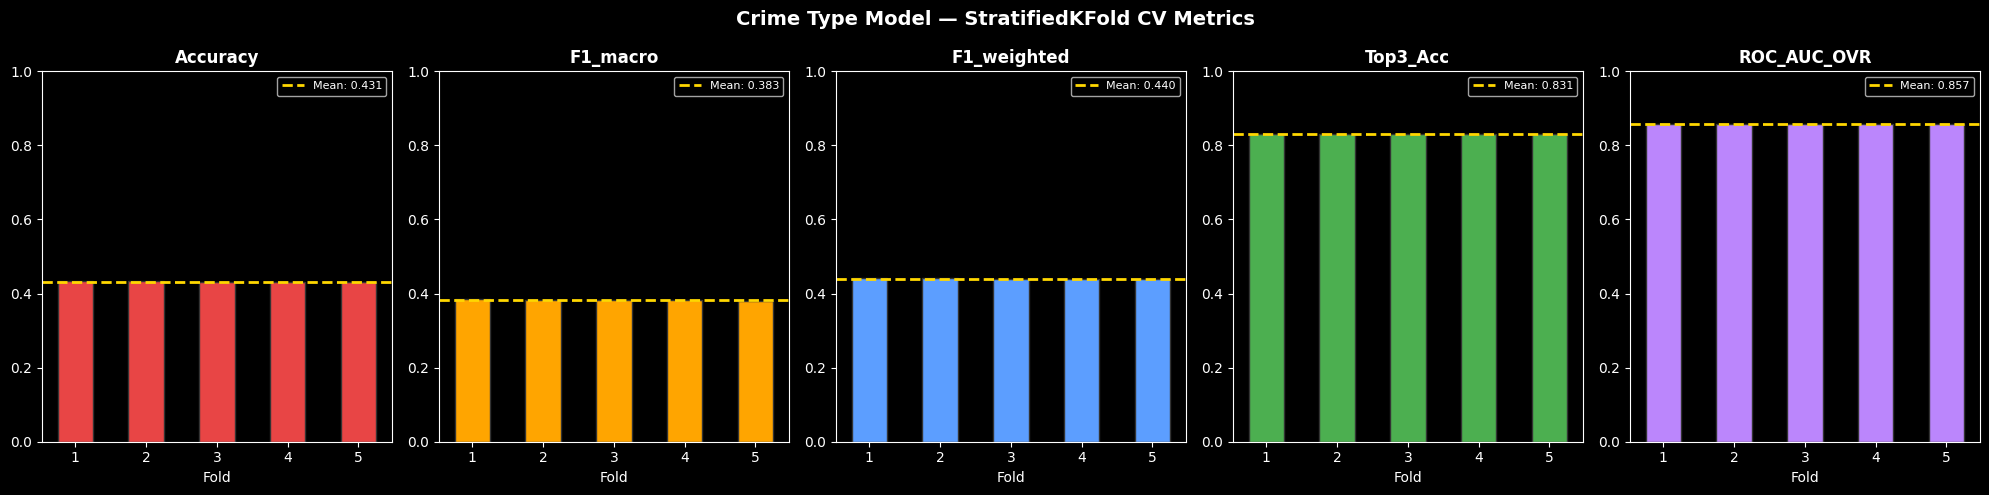

In [6]:
# ── CV metrics visual ─────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy','F1_macro','F1_weighted','Top3_Acc','ROC_AUC_OVR']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
colors = ['#E84545','#FFA500','#5C9EFF','#4CAF50','#BB86FC']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    ax.bar(cv_df['Fold'].astype(str), cv_df[metric], color=color, width=0.5, edgecolor='#333')
    ax.axhline(cv_df[metric].mean(), color='gold', linestyle='--', linewidth=2,
               label=f'Mean: {cv_df[metric].mean():.3f}')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Crime Type Model — StratifiedKFold CV Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_metrics_crime_type.png', dpi=150)
plt.show()

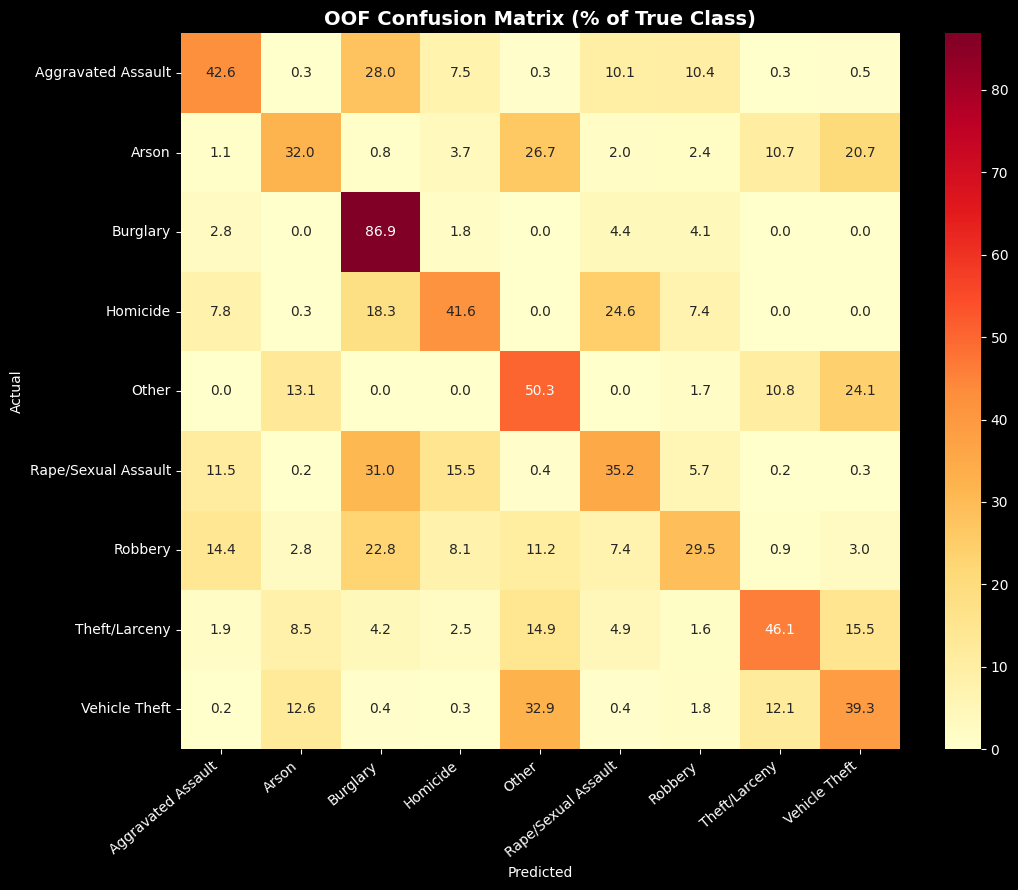

In [7]:
# ── OOF confusion matrix ──────────────────────────────────────────────────
oof_preds_cls = np.argmax(oof_proba, axis=1)
cm_oof = confusion_matrix(y_train, oof_preds_cls)
cm_oof_pct = cm_oof.astype(float) / cm_oof.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_oof_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('OOF Confusion Matrix (% of True Class)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=40, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_oof.png', dpi=150)
plt.show()

## 3️⃣ Train Final Model & Evaluate on Test Set

In [8]:
best_n = int(np.mean(best_iters)) + 50
print(f'Final n_estimators: {best_n}')

final_model = lgb.LGBMClassifier(**{**PARAMS, 'n_estimators': best_n})

with tqdm(total=best_n, desc='Training final model', unit='tree') as pbar:
    class ProgressCB:
        def __call__(self, env): pbar.update(1)
    final_model.fit(X_train, y_train,
                    callbacks=[lgb.log_evaluation(period=-1), ProgressCB()])

print('✅ Final model trained')

Final n_estimators: 848


Training final model: 100%|██████████| 848/848 [01:37<00:00,  8.66tree/s]

✅ Final model trained


In [9]:
# ── Test set evaluation ────────────────────────────────────────────────────
test_proba = final_model.predict_proba(X_test)
test_preds = np.argmax(test_proba, axis=1)

test_acc   = accuracy_score(y_test, test_preds)
test_f1_mac= f1_score(y_test, test_preds, average='macro',    zero_division=0)
test_f1_mic= f1_score(y_test, test_preds, average='micro',    zero_division=0)
test_f1_w  = f1_score(y_test, test_preds, average='weighted', zero_division=0)
test_top3  = top_k_accuracy_score(y_test, test_proba, k=3)
test_prec  = precision_score(y_test, test_preds, average='weighted', zero_division=0)
test_rec   = recall_score(y_test, test_preds, average='weighted', zero_division=0)
try:
    test_auc = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
except Exception:
    test_auc = float('nan')

print('='*60)
print('  TEST SET METRICS (2024 Only Holdout)')
print('='*60)
print(f'  Accuracy          : {test_acc:.4f}')
print(f'  F1 Macro          : {test_f1_mac:.4f}')
print(f'  F1 Micro          : {test_f1_mic:.4f}')
print(f'  F1 Weighted       : {test_f1_w:.4f}')
print(f'  Top-3 Accuracy    : {test_top3:.4f}')
print(f'  Precision (weighted): {test_prec:.4f}')
print(f'  Recall (weighted) : {test_rec:.4f}')
print(f'  ROC-AUC (OVR, w.) : {test_auc:.4f}')
print('='*60)

print('\nPer-class Classification Report (Test):')
print(classification_report(y_test, test_preds,
                            target_names=le.classes_, zero_division=0))

pd.DataFrame([{
    'Accuracy': test_acc, 'F1_macro': test_f1_mac, 'F1_micro': test_f1_mic,
    'F1_weighted': test_f1_w, 'Top3_Acc': test_top3,
    'Precision': test_prec, 'Recall': test_rec, 'ROC_AUC_OVR': test_auc
}]).to_csv(OUTPUT_DIR / 'test_metrics_crime_type.csv', index=False)

  TEST SET METRICS (2024 Only Holdout)
  Accuracy          : 0.4939
  F1 Macro          : 0.4216
  F1 Micro          : 0.4939
  F1 Weighted       : 0.4894
  Top-3 Accuracy    : 0.8460
  Precision (weighted): 0.5682
  Recall (weighted) : 0.4939
  ROC-AUC (OVR, w.) : 0.8527

Per-class Classification Report (Test):
                     precision    recall  f1-score   support

 Aggravated Assault       0.66      0.52      0.58     26878
              Arson       0.51      0.67      0.58      6889
           Burglary       0.51      0.90      0.65     23140
           Homicide       0.02      0.37      0.04       306
              Other       0.20      0.49      0.28      5110
Rape/Sexual Assault       0.31      0.31      0.31      7666
            Robbery       0.65      0.25      0.36     35187
      Theft/Larceny       0.73      0.49      0.59     11689
      Vehicle Theft       0.44      0.37      0.40     10799

           accuracy                           0.49    127664
          mac

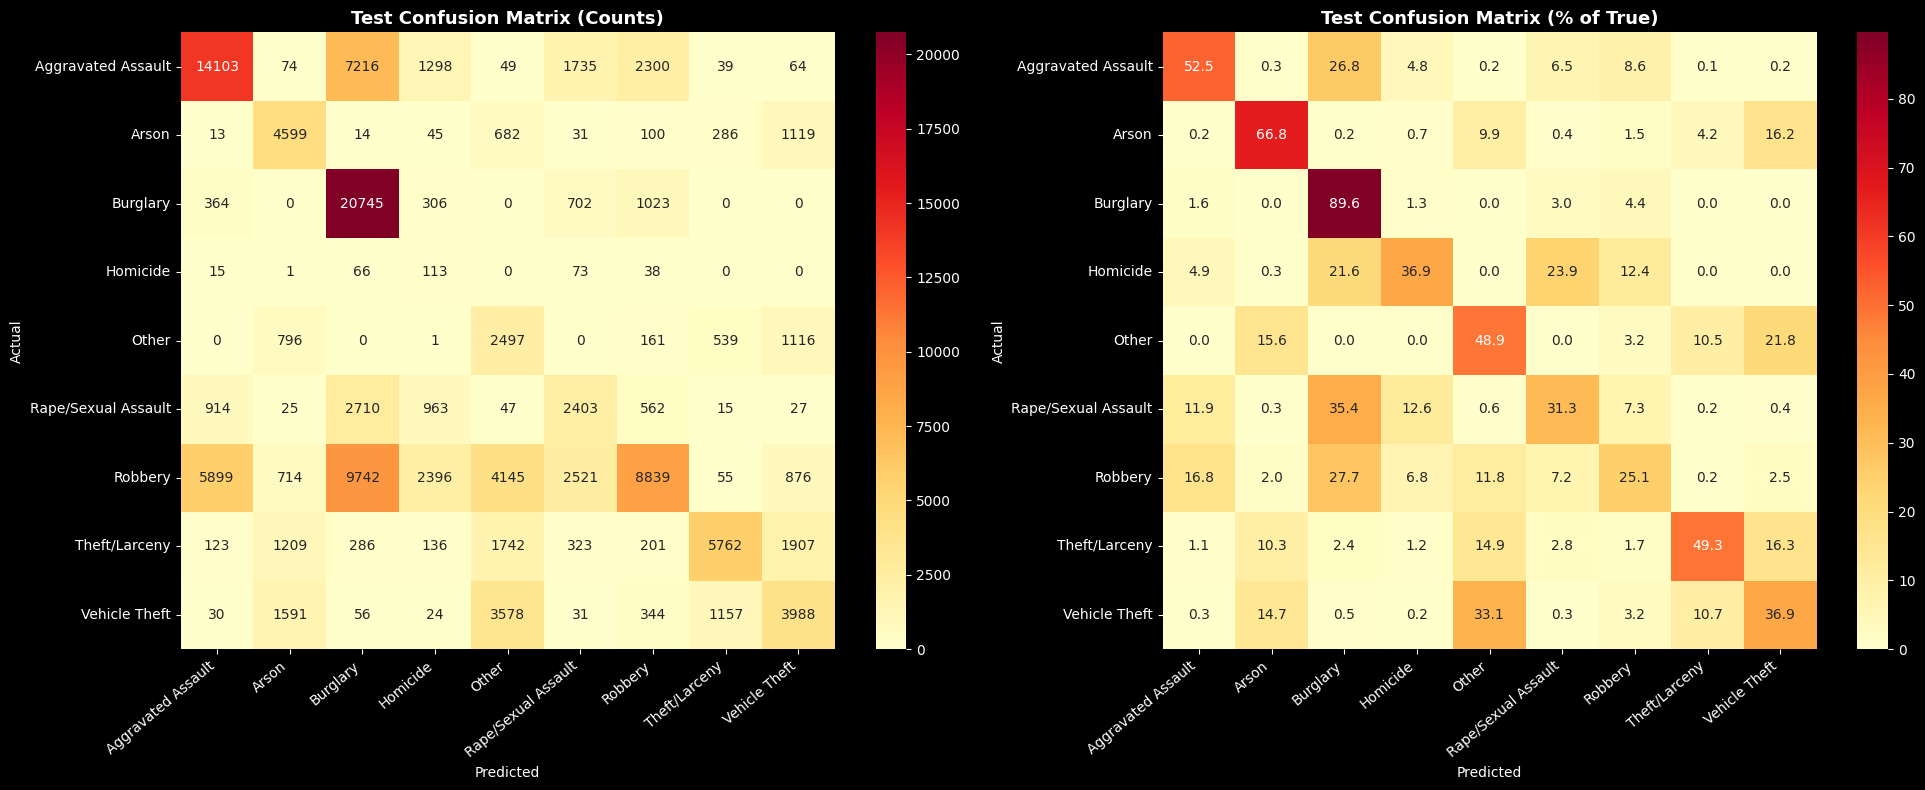

In [10]:
# ── Test confusion matrix ─────────────────────────────────────────────────
cm_test = confusion_matrix(y_test, test_preds)
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Count matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Test Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=40, ha='right')

# Percentage matrix
sns.heatmap(cm_test_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Test Confusion Matrix (% of True)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_test.png', dpi=150)
plt.show()

In [11]:
# ── Full comparison table: CV vs Test ─────────────────────────────────────
comparison = pd.DataFrame({
    'Metric'    : ['Accuracy','F1 Macro','F1 Micro','F1 Weighted','Top-3 Acc',
                   'Precision (w)','Recall (w)','ROC-AUC (w)'],
    'CV Mean'   : [cv_df['Accuracy'].mean(), cv_df['F1_macro'].mean(),
                   cv_df['F1_micro'].mean(), cv_df['F1_weighted'].mean(),
                   cv_df['Top3_Acc'].mean(), cv_df['Precision'].mean(),
                   cv_df['Recall'].mean(), cv_df['ROC_AUC_OVR'].mean()],
    'CV Std'    : [cv_df['Accuracy'].std(), cv_df['F1_macro'].std(),
                   cv_df['F1_micro'].std(), cv_df['F1_weighted'].std(),
                   cv_df['Top3_Acc'].std(), cv_df['Precision'].std(),
                   cv_df['Recall'].std(), cv_df['ROC_AUC_OVR'].std()],
    'Test 24-25': [test_acc, test_f1_mac, test_f1_mic, test_f1_w,
                   test_top3, test_prec, test_rec, test_auc],
})
comparison[['CV Mean','CV Std','Test 24-25']] = comparison[['CV Mean','CV Std','Test 24-25']].round(4)
comparison['Generalisation'] = comparison.apply(
    lambda r: '✅ Good' if abs(r['CV Mean'] - r['Test 24-25']) < 0.05 else '⚠️ Gap', axis=1
)
print('\n  FULL METRICS COMPARISON TABLE')
print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT_DIR / 'metrics_summary_crime_type.csv', index=False)


  FULL METRICS COMPARISON TABLE
       Metric  CV Mean  CV Std  Test 24-25 Generalisation
     Accuracy   0.4315  0.0016      0.4939         ⚠️ Gap
     F1 Macro   0.3826  0.0017      0.4216         ✅ Good
     F1 Micro   0.4315  0.0016      0.4939         ⚠️ Gap
  F1 Weighted   0.4401  0.0018      0.4894         ✅ Good
    Top-3 Acc   0.8307  0.0003      0.8460         ✅ Good
Precision (w)   0.5345  0.0015      0.5682         ✅ Good
   Recall (w)   0.4315  0.0016      0.4939         ⚠️ Gap
  ROC-AUC (w)   0.8574  0.0003      0.8527         ✅ Good


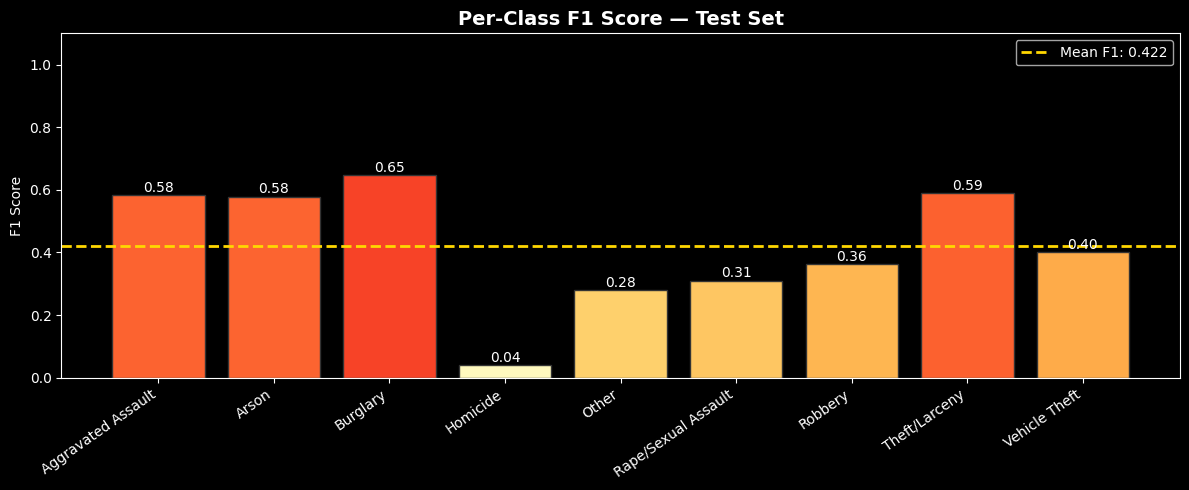

In [12]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────
from sklearn.metrics import f1_score as f1_per_class
per_class_f1 = f1_score(y_test, test_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.YlOrRd(per_class_f1)
bars = ax.bar(le.classes_, per_class_f1, color=colors, edgecolor='#333')
ax.axhline(per_class_f1.mean(), color='gold', linestyle='--', linewidth=2,
           label=f'Mean F1: {per_class_f1.mean():.3f}')
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=10)
ax.set_title('Per-Class F1 Score — Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.1)
ax.set_xticklabels(le.classes_, rotation=35, ha='right'); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_f1.png', dpi=150)
plt.show()

## 4️⃣ SHAP Explainability

Computing SHAP values (sample of 1500 rows)...


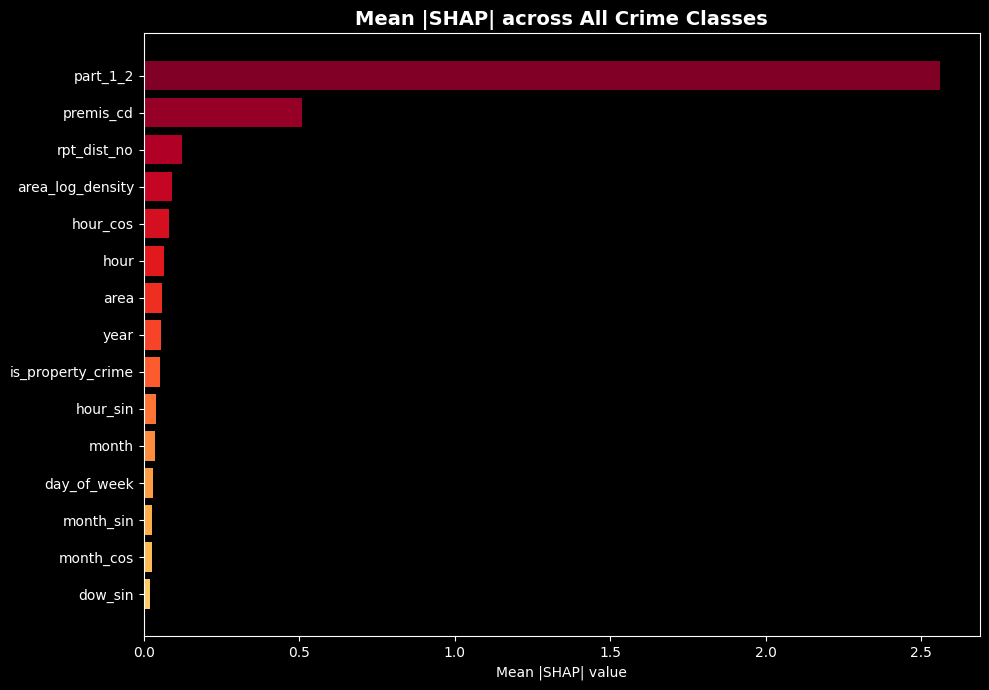

Top features by SHAP:
part_1_2             2.5613
premis_cd            0.5101
rpt_dist_no          0.1229
area_log_density     0.0902
hour_cos             0.0827
hour                 0.0649
area                 0.0602
year                 0.0544
is_property_crime    0.0539
hour_sin             0.0385


In [13]:
print('Computing SHAP values (sample of 1500 rows)...')
sample = X_train.sample(min(1500, len(X_train)), random_state=42)
exp    = shap.TreeExplainer(final_model)
sv     = exp.shap_values(sample)

# ── Handle both SHAP API versions ────────────────────────────────────────
# Newer SHAP (>=0.41): shap_values returns ndarray of shape
#   (n_samples, n_features, n_classes)  — need to transpose
# Older SHAP: returns list of (n_samples, n_features) arrays, one per class
if isinstance(sv, np.ndarray) and sv.ndim == 3:
    # shape: (n_samples, n_features, n_classes) → average |SHAP| over classes
    mean_abs_shap = np.abs(sv).mean(axis=(0, 2))  # shape: (n_features,)
    shap_fi = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)
elif isinstance(sv, list):
    # Old API: list of (n_samples, n_features) — one per class
    mean_abs_shap = np.mean([np.abs(sv[c]) for c in range(N_CLASSES)], axis=0)  # (n_samples, n_features)
    mean_abs_shap = mean_abs_shap.mean(axis=0)  # (n_features,)
    shap_fi = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)
else:
    # 2D array fallback (binary or single output)
    shap_fi = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_shap = shap_fi.head(15)
colors   = plt.cm.YlOrRd(np.linspace(0.3, 1.0, min(15, len(top_shap))))[::-1]
ax.barh(top_shap.index[::-1], top_shap.values[::-1], color=colors[::-1])
ax.set_title('Mean |SHAP| across All Crime Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean |SHAP| value')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_crime_type.png', dpi=150)
plt.show()
print(f'Top features by SHAP:\n{shap_fi.head(10).round(4).to_string()}')


## 5️⃣ Victim Profile Analysis

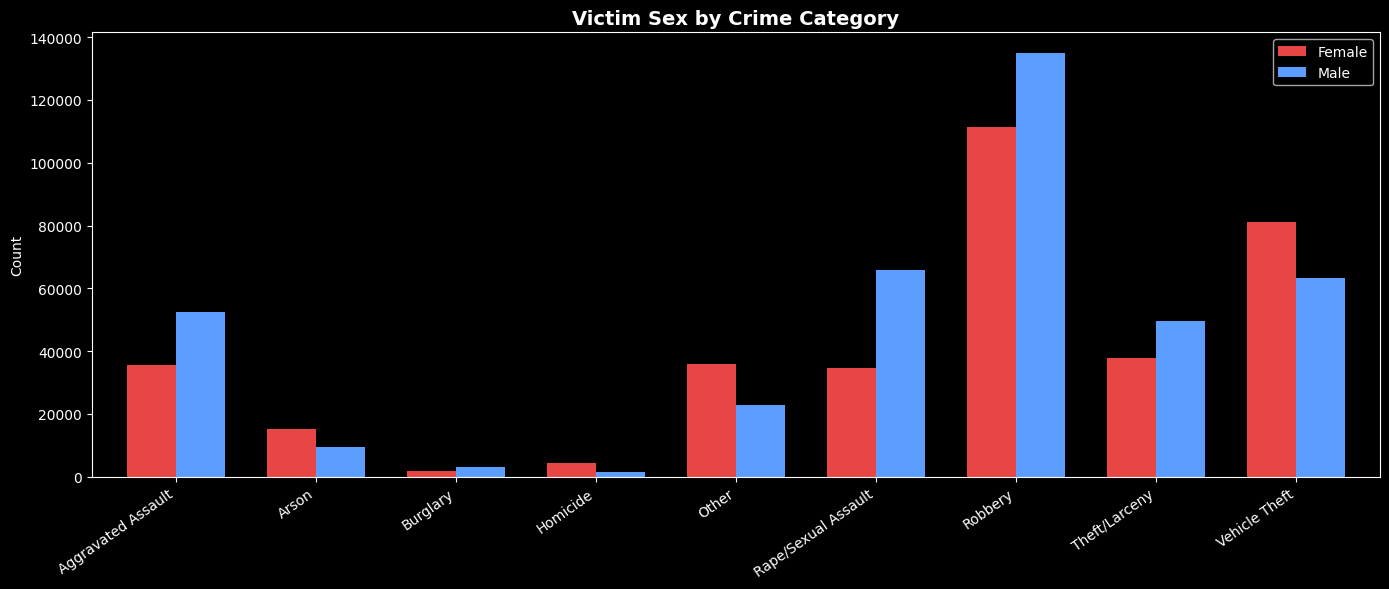

In [14]:
df_all = pd.read_parquet(DATA_DIR / 'clean_crime.parquet')

# ── Victim sex × crime category ───────────────────────────────────────────
if 'vict_sex' in df_all.columns and 'crime_category' in df_all.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    sc = df_all[df_all['vict_sex'].isin(['M','F'])].groupby(
        ['crime_category','vict_sex']
    ).size().unstack(fill_value=0)
    sc.plot(kind='bar', ax=ax, color=['#E84545','#5C9EFF'], width=0.7, edgecolor='none')
    ax.set_title('Victim Sex by Crime Category', fontsize=14, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Count')
    ax.legend(['Female','Male'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'victim_sex_by_crime.png', dpi=150)
    plt.show()

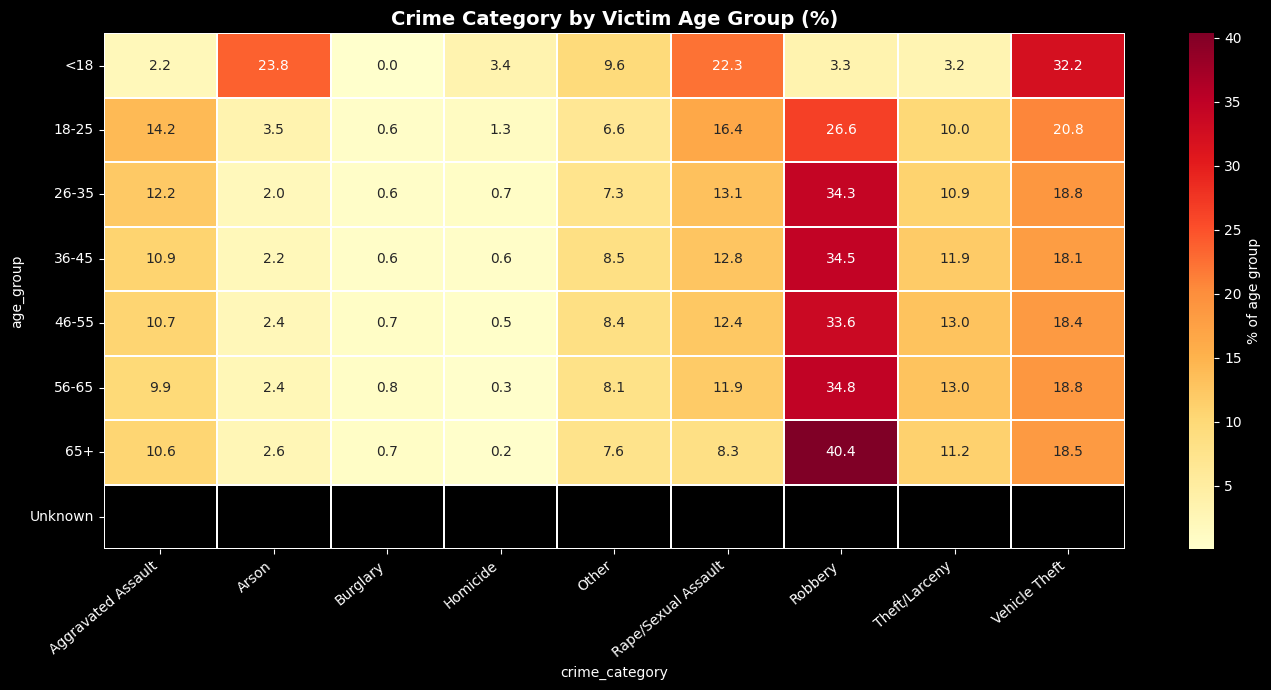

In [15]:
# ── Age group × crime heatmap ─────────────────────────────────────────────
if 'age_group' in df_all.columns and 'crime_category' in df_all.columns:
    fig, ax = plt.subplots(figsize=(14, 7))
    ac = df_all[df_all['age_group'] != 'Unknown'].groupby(
        ['age_group','crime_category']
    ).size().unstack(fill_value=0)
    ac_pct = ac.div(ac.sum(axis=1), axis=0) * 100
    sns.heatmap(ac_pct, cmap='YlOrRd', ax=ax, annot=True, fmt='.1f',
                linewidths=0.3, cbar_kws={'label': '% of age group'})
    ax.set_title('Crime Category by Victim Age Group (%)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=40, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'victim_age_crime_heatmap.png', dpi=150)
    plt.show()

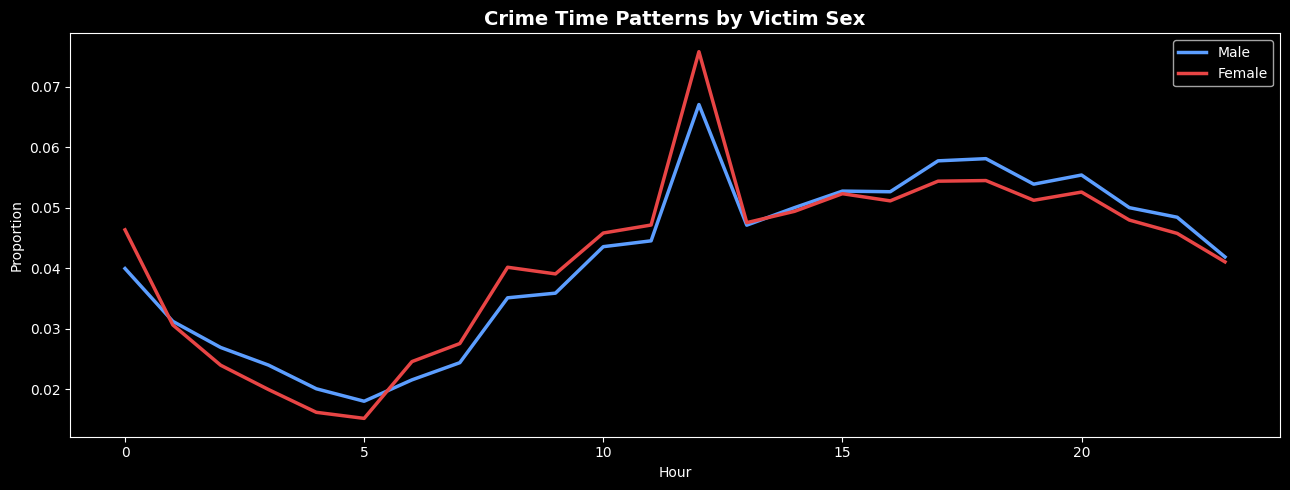

In [16]:
# ── Hourly crime pattern by sex ────────────────────────────────────────────
if 'vict_sex' in df_all.columns:
    fig, ax = plt.subplots(figsize=(13, 5))
    for sex, color, lbl in [('M','#5C9EFF','Male'),('F','#E84545','Female')]:
        sub = df_all[df_all['vict_sex'] == sex].groupby('hour').size()
        sub = sub / sub.sum()
        ax.plot(sub.index, sub.values, color=color, linewidth=2.5, label=lbl)
    ax.set_title('Crime Time Patterns by Victim Sex', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hour'); ax.set_ylabel('Proportion'); ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'victim_sex_hourly.png', dpi=150)
    plt.show()

## 6️⃣ Save Model

In [17]:
joblib.dump(final_model,  MODEL_DIR / 'crime_type_model.pkl')
joblib.dump(le,           MODEL_DIR / 'crime_type_label_encoder.pkl')
joblib.dump(FEATURE_COLS, MODEL_DIR / 'crime_type_features.pkl')

print('✅ All models saved.')
print(f'  crime_type_model.pkl')
print(f'  crime_type_label_encoder.pkl')
print(f'  crime_type_features.pkl')

# Quick sanity check
sample_proba = final_model.predict_proba(X_test.head(3))
print('\nSample predictions (top class):')
for i, p in enumerate(sample_proba):
    pred_class = le.classes_[np.argmax(p)]
    true_class = le.classes_[y_test[i]]
    print(f'  Predicted: {pred_class:<22} | Actual: {true_class}')

✅ All models saved.
  crime_type_model.pkl
  crime_type_label_encoder.pkl
  crime_type_features.pkl

Sample predictions (top class):
  Predicted: Burglary               | Actual: Aggravated Assault
  Predicted: Vehicle Theft          | Actual: Vehicle Theft
  Predicted: Burglary               | Actual: Aggravated Assault
